In [7]:
import pandas as pd
import numpy as np

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt

In [8]:
df = pd.read_csv('../data/processed_fraud_data.csv')

print("Shape:", df.shape)
df.head()

Shape: (506691, 438)


,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,day,tx_per_day,email_user_count,device_user_count,device_count,email_count,card1_freq,card2_freq,addr1_freq,P_emaildomain_freq
0,9002.840833,50.00,1,1001,555.0,150.0,4,226.0,2,269.0,...,375.0,1,3190,6409,2,2,2,38409,5752,40399
1,9192.758889,39.00,4,1001,555.0,150.0,4,226.0,2,269.0,...,383.0,1,4156,9154,2,2,2,38409,5752,69192
2,9356.059444,60.00,1,1002,-999.0,150.0,2,-999.0,1,343.0,...,389.0,1,8643,5107,1,1,1,8654,1473,207448
3,8145.514167,42.95,4,1003,452.0,150.0,2,224.0,2,264.0,...,339.0,1,5295,9154,1,1,1,1332,32710,81850
4,8715.396389,100.00,1,1004,583.0,150.0,4,226.0,1,325.0,...,363.0,1,2473,6409,1,3,3,19700,34151,24048


In [9]:
X = df.copy()


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
model = IsolationForest(
    n_estimators=200,
    contamination=0.02,  # assume ~2% fraud
    random_state=42
)

model.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.02
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [12]:
# -1 = anomaly (fraud), 1 = normal
pred = model.predict(X_scaled)

df['anomaly'] = pred

# Convert to 1 = fraud, 0 = normal
df['fraud_flag'] = np.where(df['anomaly'] == -1, 1, 0)

df['fraud_flag'].value_counts()

C:\Users\zibsh\AppData\Local\Temp\ipykernel_1096\3680651038.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['anomaly'] = pred
C:\Users\zibsh\AppData\Local\Temp\ipykernel_1096\3680651038.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['fraud_flag'] = np.where(df['anomaly'] == -1, 1, 0)


fraud_flag
0    496557
1     10134
Name: count, dtype: int64

In [13]:
# Higher negative score = more suspicious
df['anomaly_score'] = model.decision_function(X_scaled)

df[['anomaly_score', 'fraud_flag']].head()

C:\Users\zibsh\AppData\Local\Temp\ipykernel_1096\754784906.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['anomaly_score'] = model.decision_function(X_scaled)


,anomaly_score,fraud_flag
0,0.130904,0
1,0.218809,0
2,0.159568,0
3,0.261064,0
4,0.177744,0


In [14]:
top_fraud = df.sort_values('anomaly_score').head(20)

top_fraud

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,device_user_count,device_count,email_count,card1_freq,card2_freq,addr1_freq,P_emaildomain_freq,anomaly,fraud_flag,anomaly_score
394241,5521.875278,2000.0,2,15063,514.0,150.0,4,226.0,1,343.0,...,6409,3,38,2060,12684,1473,34064,-1,1,-0.135203
394242,5521.943889,2000.0,2,15063,514.0,150.0,4,226.0,1,343.0,...,6409,3,38,2060,12684,1473,34064,-1,1,-0.134372
394240,5521.825833,2000.0,2,15063,514.0,150.0,4,226.0,1,343.0,...,6409,3,38,2060,12684,1473,34064,-1,1,-0.134194
109393,5198.644722,200.0,3,5411,543.0,150.0,2,195.0,2,184.0,...,6409,2,1,13,4517,12045,69192,-1,1,-0.131713
394246,5522.684444,1000.0,2,15063,514.0,150.0,4,226.0,1,343.0,...,6409,3,38,2060,12684,1473,34064,-1,1,-0.130769
394243,5522.210000,2000.0,2,15063,514.0,150.0,4,226.0,1,343.0,...,6409,3,38,2060,12684,1473,34064,-1,1,-0.129015
76882,5875.836389,30.0,3,3962,337.0,150.0,4,195.0,2,330.0,...,6409,3,5,88,292,22100,69192,-1,1,-0.127192
384694,5281.039444,40.0,3,14479,387.0,150.0,4,226.0,1,330.0,...,9154,3,20,499,500,22100,69192,-1,1,-0.126340
76879,5854.809167,10.0,3,3962,337.0,150.0,4,195.0,2,330.0,...,6409,3,5,88,292,22100,69192,-1,1,-0.123544
384700,5305.033333,75.0,3,14479,387.0,150.0,4,226.0,1,330.0,...,9154,3,20,499,500,22100,69192,-1,1,-0.121535


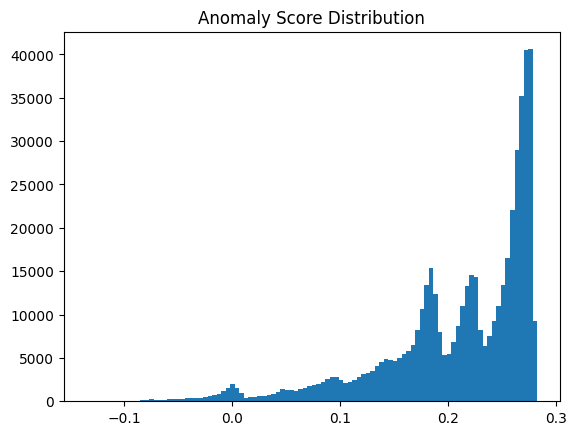

In [15]:
plt.hist(df['anomaly_score'], bins=100)
plt.title("Anomaly Score Distribution")
plt.show()

In [18]:
df.head()

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,device_user_count,device_count,email_count,card1_freq,card2_freq,addr1_freq,P_emaildomain_freq,anomaly,fraud_flag,anomaly_score
0,9002.840833,50.00,1,1001,555.0,150.0,4,226.0,2,269.0,...,6409,2,2,2,38409,5752,40399,1,0,0.130904
1,9192.758889,39.00,4,1001,555.0,150.0,4,226.0,2,269.0,...,9154,2,2,2,38409,5752,69192,1,0,0.218809
2,9356.059444,60.00,1,1002,-999.0,150.0,2,-999.0,1,343.0,...,5107,1,1,1,8654,1473,207448,1,0,0.159568
3,8145.514167,42.95,4,1003,452.0,150.0,2,224.0,2,264.0,...,9154,1,1,1,1332,32710,81850,1,0,0.261064
4,8715.396389,100.00,1,1004,583.0,150.0,4,226.0,1,325.0,...,6409,1,3,3,19700,34151,24048,1,0,0.177744


In [16]:
df.to_csv('../data/fraud_unsupervised_results.csv', index=False)

In [19]:
df[df['fraud_flag'] == 1].head()

,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,...,device_user_count,device_count,email_count,card1_freq,card2_freq,addr1_freq,P_emaildomain_freq,anomaly,fraud_flag,anomaly_score
20,5992.885833,75.0,2,1009,399.0,150.0,0,146.0,1,181.0,...,6409,2,4,12,6278,11554,207448,-1,1,-0.032823
21,5994.212222,75.0,2,1009,399.0,150.0,0,146.0,1,181.0,...,6409,2,4,12,6278,11554,207448,-1,1,-0.037739
806,6287.312778,100.0,2,1062,555.0,150.0,4,226.0,1,469.0,...,6409,1,1,1,38409,2805,207448,-1,1,-0.045401
890,6164.129444,100.0,1,1071,555.0,131.0,2,126.0,2,432.0,...,6409,1,1,2,38409,44,207448,-1,1,-0.046624
893,5694.235833,100.0,1,1076,555.0,106.0,4,137.0,2,296.0,...,9154,3,4,13,38409,422,40399,-1,1,-0.085264
